In [1]:
MODEL_CLS = "ae"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{MODEL_CLS}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M1-PJT_ML


In [4]:
import sys
sys.path.append("src")

# Packages

In [5]:
import pandas as pd
from anomaly.deterministic import config, pipeline, trainer, evaluator, utils
import autoencoder

In [ ]:
cfg = config.builder.config_builder(PATH_CONFIG_FILE)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/creditcard.csv"
origin = pd.read_csv(PATH)

In [9]:
DROP_COL = ["Time", "Amount"]
df = origin.drop(columns=DROP_COL)

In [10]:
Y_COL = "Class"

kwargs = dict(
    df=df,
    y_col=Y_COL,
    cfg=cfg.pipeline,
)

dataloaders = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    **cfg.model.params,
)

model = autoencoder.ae.AutoEncoder(**kwargs)

# Train

In [12]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [13]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.0872
	BEST EPOCH: 33


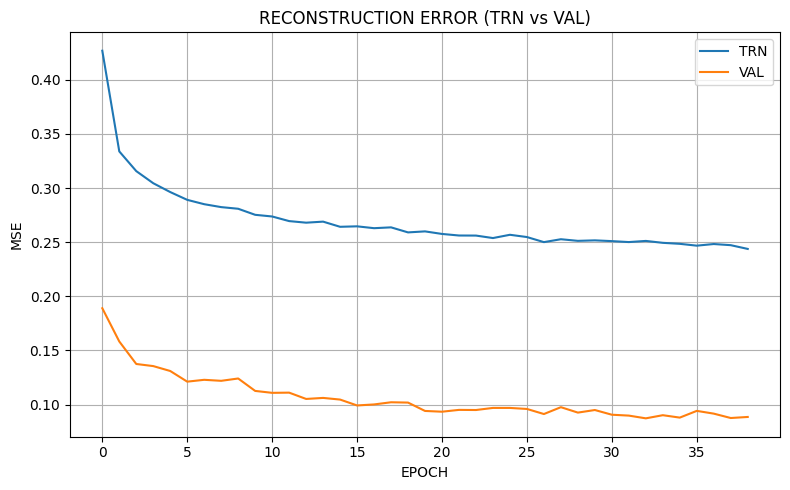

In [21]:
kwargs = dict(
    objs=(records["trn"], records["val"]),
    labels=("TRN", "VAL"),
    xlabel="EPOCH",
    ylabel="MSE",
    title="RECONSTRUCTION ERROR (TRN vs VAL)",
    figsize=(8,5),
)

utils.visualizer.main(**kwargs)

# Evaluation

In [15]:
kwargs = dict(
    model=model,
    scores=records["anomaly"],
    cfg=cfg.evaluator,
)

eval = evaluator.builder.evaluator_builder(**kwargs)

In [16]:
result, metrics_sheet = eval(dataloaders["tst"])

TST: 100%|██████████| 8/8 [00:00<00:00, 511.71it/s]


In [17]:
metrics_sheet

,p,threshold,tp,tn,fp,fn,accuracy,precision,recall,f1
0,0.950,0.215038,434,471,21,58,0.919715,0.953846,0.882114,0.916579
1,0.955,0.228115,432,473,19,60,0.919715,0.957871,0.878049,0.916225
2,0.960,0.246809,429,475,17,63,0.918699,0.961883,0.871951,0.914712
3,0.965,0.269964,425,478,14,67,0.917683,0.968109,0.863821,0.912997
4,0.970,0.301916,421,480,12,71,0.915650,0.972286,0.855691,0.910270
5,0.975,0.338918,419,483,9,73,0.916667,0.978972,0.851626,0.910870
6,0.980,0.390512,416,487,5,76,0.917683,0.988124,0.845528,0.911281
7,0.985,0.486628,413,489,3,79,0.916667,0.992788,0.839431,0.909692
8,0.990,0.679271,410,490,2,82,0.914634,0.995146,0.833333,0.907080
9,0.995,1.133023,400,491,1,92,0.905488,0.997506,0.813008,0.895857


# Save

In [ ]:
PATH = f'./result/score/{cfg.model_cls}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
result.to_csv(**kwargs)

In [ ]:
PATH = f'./result/metric/{cfg.model_cls}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
metrics_sheet.to_csv(**kwargs)

In [20]:
PATH = f'./checkpoints/{cfg.model_cls}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)